# NB1 — Well Data Import, QC & Visualization (REVISED)

## Tujuan
Import LAS, QC log (despike MAD + null handling + clipping fisik), konversi unit,
slice ke interval geologi, ekstrapolasi TWT, hitung derived columns (PI/SI/VPVS),
dan simpan output untuk NB2.

## Input
- LAS files Poseidon-1, Boreas-1
- `pipeline_io.py`, `plot_utils.py` (foundation modules)

## Output (`pipeline_data/01_well_qc/`)
- `CFG.pkl` — konfigurasi global terstandardisasi
- `WELL_TOPS.pkl` — formation tops per sumur
- `<wellname>.parquet` — DataFrame log pasca-QC (Poseidon-1, Boreas-1)
- `metadata.json` — ringkasan
- `empirical_clip_bounds.json` — batas P1-P99 dari data (untuk P10 fix di NB2/NB6)

## Perbaikan dari versi lama
- **P10**: Empirical clipping bounds dihitung dari data (P1-P99) dan disimpan ke CFG
- **P11**: `rho_clay` di-set 2.55 di CFG (sebelumnya inkonsisten 2.58)
- **P12**: TIME extrapolation dilakukan SETELAH slice formasi (sudah benar di versi lama, dipertegas)
- **P13**: Plot 9-track menggunakan `plot_utils.plot_well_logs_9track` (template baru)
- **CFG**: Parameter baru untuk kalibrasi otomatis di NB6 (`calibrate_*`, `lateral_blend_lambda`, `n_pseudo_wells`, `n_qsamp`)


## Cell 1 — Imports + Foundation modules

In [9]:
import os, sys, gc, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Foundation modules harus berada di folder yang sama dengan notebook
sys.path.insert(0, str(Path.cwd()))
from pipeline_io import PipelineIO
import plot_utils

try:
    import lasio
    HAS_LASIO = True
except ImportError:
    HAS_LASIO = False
    print("[WARN] lasio tidak terinstall — fallback synthetic well")

warnings.filterwarnings("ignore")
np.random.seed(42)

print("=" * 72)
print("  NB1 — WELL DATA IMPORT, QC & VISUALIZATION")
print("=" * 72)
print(f"  Python  : {sys.version.split()[0]}")
print(f"  numpy   : {np.__version__}")
print(f"  pandas  : {pd.__version__}")
print(f"  lasio   : {'OK' if HAS_LASIO else 'MISSING'}")


  NB1 — WELL DATA IMPORT, QC & VISUALIZATION
  Python  : 3.12.4
  numpy   : 2.3.3
  pandas  : 2.3.3
  lasio   : OK


## Cell 2 — Konfigurasi global `CFG`

Disimpan sebagai pickle agar NB2-NB6 menggunakan konfigurasi yang sama persis.

In [10]:
CFG = {
    # ───── 1D seismic CSV (legacy 1D pipeline) ─────
    "seismic_1d": {
        "csv_file"    : Path(r"E:\PY\numpy_project\TA\export_results\seis_input\Seismic_Cut_Montara_Nome_4.csv"),
        "horizon_file": Path(r"E:\TA\Data\Horizon\Arbitary4_horizon.txt"),
        "dt_s"        : 0.004,
        "theta_deg"   : [12.0, 24.0, 36.0],
    },

    # ───── Wavelet ─────
    "wavelet": {
        "file"            : Path(r"E:\TA\Data\Wavelet\statistical_120_Clean.txt"),
        "fallback_freq_hz": 24.0,
        "fallback_n"      : 81,
    },

    # ───── Wells ─────
    "wells": {
        "Poseidon-1": {
            "las_file"  : Path(r"E:\TA\Data\Well\Well Conditioning\Poseidon 1_last.las"),
            "trace_idx" : 415,
            "tops": {
                "Montara Fm."           : 4628.6963,
                "Plover Volcanics Fm."  : 4686.8999,
                "Plover Reservoir Fm."  : 4799.8301,
                "Nome Fm."              : 5037.0386,
            },
            "depth_rpm_start_key": "Montara Fm.",
            "depth_rpm_end"      : 5100,
            "lith_cfg": {"vsh_cutoff": 0.35, "sw_cutoff": 0.30, "phie_cutoff": 0.08},

            # Mineral
            "K_min": 36.0, "G_min": 45.0, "Rho_min": 2.65,
            # Frame
            "Crit_Phi": 0.37, "Pressure": 55.0, "Coord_num": 9.0, "Nu_min": 0.08,
            # Brine
            "K_fl_brine": 2.25, "Rho_brine": 1.04,
            # Cement
            "C_cement": 0.03, "K_cement": 36.0, "G_cement": 45.0, "Nu_cement": 0.08,
            # Gas
            "K_gas": 0.03, "rho_gas": 0.20,
        },
        "Boreas-1": {
            "las_file" : Path(r"E:\TA\Data\Well\Well Conditioning\Boreas 1_last1.las"),
            "trace_idx": 603,
            "tops": {
                "Montara Fm."           : 4675.4302,
                "Plover Volcanics Fm."  : 4775.8799,
                "Plover Reservoir Fm."  : 4882.3779,
                "Nome Fm."              : 5073.6196,
            },
            "depth_rpm_start_key": "Montara Fm.",
            "depth_rpm_end"      : 5050,
            "lith_cfg": {"vsh_cutoff": 0.40, "sw_cutoff": 0.30, "phie_cutoff": 0.08},
            "K_min": 36.0, "G_min": 45.0, "Rho_min": 2.65,
            "Crit_Phi": 0.37, "Pressure": 50.0, "Coord_num": 9.0, "Nu_min": 0.08,
            "K_fl_brine": 2.30, "Rho_brine": 1.05,
            "C_cement": 0.04, "K_cement": 36.0, "G_cement": 45.0, "Nu_cement": 0.08,
            "K_gas": 0.03, "rho_gas": 0.20,
        },
    },

    # ───── QC (despike + clip) ─────
    "qc": {
        "spike_window": 5,
        "spike_thresh": 3.0,
        "clip": {
            "SW"  : (0.0, 1.0),
            "PHIE": (0.0, 0.30),
            "GR"  : (0.0, 200.),
            "VSH" : (0.0, 1.0),
            "VP"  : (1500, 6500),
            "VS"  : (500,  4000),
            "RHOB": (2.0,  3.0),
        },
    },

    # ───── Geological interval ─────
    "geology": {"top_start": "Montara Fm.", "top_end": None},

    # ───── Lithology rule-based fallback ─────
    "lithology": {
        "gr_percentile": 35,
        "vsh_cutoff"   : 0.5,
        "sw_cutoff"    : 0.30,
        "phie_cutoff"  : 0.08,
        "rt_cutoff"    : 10.0,
    },

    # ───── GMM training (P9 fix: full Montara→Nome) ─────
    "facies_gmm": {
        "training_top" : "Plover Volcanics Fm.",        # ← P9: was "Plover Volcanics Fm."
        "training_base": "Nome Fm.",
        "features"     : ["PHIE", "VSH", "SW", "VP", "VS", "RHOB", "LR", "MR", "RD"],
        "n_components" : 3,
    },

    # ───── Rock physics (P11 fix: rho_clay = 2.55) ─────
    "rock_physics" : {
        "K_qtz"    : 36.0,
        "K_clay"   : 25.0,
        "mu_qtz"   : 45.0,
        "mu_clay"  : 9.0,
        "rho_qtz"  : 2.65,
        "rho_clay" : 2.55,    # ← P11: was 2.58, now consistent with NB2
        "K_brine"  : 2.28,
        "K_gas"    : 0.03,
        "rho_brine": 1.05,
        "rho_gas"  : 0.20,
        "brie_e"   : 7.0,
        "P_eff_MPa": 52.5,
        "n_coord"  : 9.0,
        "phi_c"    : 0.37,
        "nu_min"   : 0.08,
        "K_cement" : 36.0,
        "G_cement" : 45.0,
        "nu_cem"   : 0.08,
        "c_cement" : 0.035,
    },

    # ───── Multi-trace extraction ─────
    "multi_trace": {"n_offset": 2, "stack_method": "mean"},

    # ───── 2D SEGY ─────
    "seismic_2d": {
        "segy_near"   : Path(r"E:\TA\TA_Test_Baru.prj\seismic.dir\arbitrary2_Near.sgy"),
        "segy_mid"    : Path(r"E:\TA\TA_Test_Baru.prj\seismic.dir\arbitrary2_Mid.sgy"),
        "segy_far"    : Path(r"E:\TA\TA_Test_Baru.prj\seismic.dir\arbitrary2_Far.sgy"),
        "horizon_file": Path(r"E:\TA\Data\Horizon\Arbitary4_horizon.txt"),
        "wavelet_full": Path(r"E:\TA\Data\Wavelet\statistical_120_Clean.txt"),
        "TOP_TWT"   : 2000.0,
        "BOTTOM_TWT": 4000.0,
        "TRACE_MIN" : 0,
        "TRACE_MAX" : 999,
    },

    # ───── Horizon ─────
    "horizon": {
        "USE": True, "TOP_HORIZON": "Montara", "BOT_HORIZON": "Nome",
        "PADDING_MS": 4.0, "NULL_VAL": -1.0e+21,
        "STYLES": {
            "Montara": dict(color="lime", lw=1.5, ls="-"),
            "Nome": dict(color="orange", lw=1.5, ls="--"),
            "Plover Reservoir": dict(color="magenta", lw=1.5, ls="--"),
            "Plover Volcanics": dict(color="red", lw=2.0, ls="-"),
        },
    },

    # ───── LFM ─────
    "lfm": {
        "filter_freq_hz"      : 20,
        "idw_power"           : 2.0,
        "flatten_by_horizons" : True,
        "n_pseudo_wells"      : 10,        # ← P8: pseudo-wells untuk auto-linear
        "n_pseudo_left"       : 10,
        "n_pseudo_left"       : 10,
        "pseudo_well_strategy": "auto_linear",
        "range_traces_factor" : 0.50,    # ← P8: range = factor × inter-well distance
    },

    # ───── 2D Bayesian inversion ─────
    "inversion_2d": {
        "theta_deg"             : [12, 24, 36],
        "corr_length_ms"        : 8.0,                 # default; akan dikalibrasi
        "sigma0"                : [[0.0034, 0.0037, 0.0014],
                                   [0.0037, 0.0042, 0.0012],
                                   [0.0014, 0.0012, 0.0015]],
        "noise_var"             : 1.0e-2,
        "noise_scale_per_angle" : [1.0, 1.5, 2.5],
        "chunk_traces"          : 20,
        "inversion_units"       : [
            {"name": "Montara - Nome", "top": "Montara", "bottom": "Nome"},
        ],

        # ───── Calibration switches (P3, P4, P5) ─────
        "calibrate_corr_length": True,        # P3: grid search [4,6,8,12,16] ms
        "calibrate_sigma0"     : True,        # P4: dari well log
        "calibrate_noise"      : True,        # P5: dari NB4 residual
        "corr_length_grid_ms"  : [4.0, 6.0, 8.0, 12.0],

        # ───── Monte Carlo + lateral (P6, P7) ─────
        "n_qsamp"             : 20000,          # P6: was 80
        "lateral_blend_lambda": 0.25,         # P7: 0=full posterior, 1=full LFM
        "lateral_smooth_sigma_trace": 2.0,    # P7: filter sigma in trace direction
        "lateral_smooth_sigma_time" : 1.0,
    },

    # ───── RPM grid (legacy) ─────
    "rpm_grid": {
        "ndiscr_petro"  : 500, "ndiscr_elastic": 500,
        "phi_range" : [0.01, 0.30], "clay_range": [0.05, 0.95], "sw_range": [0.05, 0.95],
        "vp_range" : [1500., 6000.], "vs_range" : [500., 3500.], "rho_range" : [2.00, 3.00],
        "rp_noise_var": 5.0e-2,
    },

    # ───── Well conditioning 2D (NB5) ─────
    "well_cond_2d": {
        "cutoff_formation": "Montara Fm.",
        "despike": {
            "threshold": 7.5, "window": 11,
            "logs": ["VP", "VS", "RHOB", "PHIE", "SW", "VSH", "GR"],
        },
    },
}

# ───── Aliases ─────
DT        = CFG["seismic_1d"]["dt_s"]
WELL_CFGS = CFG["wells"]
WELL_CFG  = CFG["wells"]

print("=" * 72)
print(f"  Wells     : {[(k, v['trace_idx']) for k, v in WELL_CFGS.items()]}")
print(f"  Interval  : {CFG['geology']['top_start']} → {CFG['geology']['top_end'] or 'TD'}")
print(f"  dt seismic: {DT*1000:.1f} ms")
print(f"  RPM       : phi_c={CFG['rock_physics']['phi_c']} | "
      f"P_eff={CFG['rock_physics']['P_eff_MPa']} MPa | "
      f"rho_clay={CFG['rock_physics']['rho_clay']} g/cc")
print(f"  GMM       : {CFG['facies_gmm']['n_components']} komponen | "
      f"training {CFG['facies_gmm']['training_top']} → {CFG['facies_gmm']['training_base']}")
print(f"  Inversion : N_QSAMP={CFG['inversion_2d']['n_qsamp']} | "
      f"λ_blend={CFG['inversion_2d']['lateral_blend_lambda']} | "
      f"calibrate_corr_length={CFG['inversion_2d']['calibrate_corr_length']}")
print(f"  LFM       : {CFG['lfm']['n_pseudo_wells']} pseudo-wells ({CFG['lfm']['pseudo_well_strategy']})")
print("=" * 72)
print("  ✓ Konfigurasi global aktif")


  Wells     : [('Poseidon-1', 415), ('Boreas-1', 603)]
  Interval  : Montara Fm. → TD
  dt seismic: 4.0 ms
  RPM       : phi_c=0.37 | P_eff=52.5 MPa | rho_clay=2.55 g/cc
  GMM       : 3 komponen | training Plover Volcanics Fm. → Nome Fm.
  Inversion : N_QSAMP=20000 | λ_blend=0.25 | calibrate_corr_length=True
  LFM       : 10 pseudo-wells (auto_linear)
  ✓ Konfigurasi global aktif


## Cell 3 — Helper functions: LAS reader, QC, despike, slice

In [11]:
def lookup_top(formation, tops_dict):
    """Fuzzy lookup: 'Montara' == 'Montara Fm.' == 'montara fm'."""
    if not tops_dict: return None
    if formation in tops_dict:
        return float(tops_dict[formation])
    target = formation.replace(" Fm.", "").replace(" Fm", "").lower().strip()
    for k, v in tops_dict.items():
        kk = k.replace(" Fm.", "").replace(" Fm", "").lower().strip()
        if kk == target:
            return float(v)
    return None


def read_las_file(filepath):
    """Read LAS + parse 'Tops' block."""
    if not HAS_LASIO:
        raise RuntimeError("lasio is not installed.")
    filepath = Path(filepath)
    if not filepath.exists():
        raise FileNotFoundError(f"LAS not found: {filepath}")

    las = lasio.read(str(filepath))
    data = {"DEPTH": las["DEPTH"]}
    for c in las.curves:
        if c.mnemonic != "DEPTH":
            data[c.mnemonic] = las[c.mnemonic]
    df = pd.DataFrame(data)

    # Parse 'Tops' block from raw text
    tops = {}
    with open(filepath, "r", encoding="latin-1") as fh:
        content = fh.read()
    in_tops = False
    for line in content.split("\n"):
        if "Tops" in line and "~" in line:
            in_tops = True; continue
        if line.startswith("~") and in_tops:
            break
        if in_tops and line.strip() and not line.startswith("#"):
            parts = line.split()
            if len(parts) >= 3:
                try:
                    tops[" ".join(parts[:-2])] = float(parts[-1])
                except ValueError:
                    pass
    return df, tops


def make_synthetic_well_data(well_id, n=2000, seed=42):
    """Synthetic fallback when LAS not available."""
    rng = np.random.default_rng(seed + (hash(well_id) % 1000))
    depth = np.linspace(2500, 4500, n)
    gr   = 50 + 30*np.sin(depth/100) + 10*rng.standard_normal(n)
    vsh  = np.clip((gr - 30) / 80, 0, 1)
    phie = np.clip(0.18 - 0.10*vsh + 0.02*rng.standard_normal(n), 0.001, 0.30)
    sw   = np.clip(0.5 + 0.4*vsh + 0.1*rng.standard_normal(n), 0.05, 1.0)
    vp   = 2200 + 1500*(1-phie) + 200*vsh + 50*rng.standard_normal(n)
    vs   = vp/1.85 + 30*rng.standard_normal(n)
    rhob = 2.0 + 0.7*(1-phie) + 0.05*vsh + 0.02*rng.standard_normal(n)
    nphi = phie + 0.05*vsh + 0.005*rng.standard_normal(n)
    md_step = depth[1] - depth[0]
    twt_s   = np.cumsum(2.0 * md_step / vp) + 2.0
    df = pd.DataFrame({"DEPTH": depth, "GR": gr, "VSH": vsh, "PHIE": phie,
                       "SW": sw, "VP": vp, "VS": vs, "RHOB": rhob,
                       "NPHI": nphi, "TIME": twt_s})
    tops = {
        "Echuca Shoals"   : depth[int(0.05*n)],
        "Jamieson"        : depth[int(0.18*n)],
        "Montara Fm."     : depth[int(0.32*n)],
        "Nome Fm."        : depth[int(0.65*n)],
        "Plover Reservoir": depth[int(0.78*n)],
        "Plover Volcanics": depth[int(0.92*n)],
    }
    return df, tops


def select_columns(df):
    """Standardize column set; replace -999.25 with NaN."""
    keep = ["DEPTH","GR","NPHI","RHOB","RS","RD","RT",
            "VP","VS","TIME","PHIE","SW","VSH","LR","MR"]
    out = df[[c for c in keep if c in df.columns]].copy()
    return out.replace(-999.25, np.nan)


def qc_spike_removal(df, qc_cfg):
    """MAD-based despike for selected logs."""
    cols = ["GR","NPHI","RHOB","VP","VS","RD","RS","RT"]
    win, thr = qc_cfg["spike_window"], qc_cfg["spike_thresh"]
    df = df.copy()
    n_total = 0
    for col in cols:
        if col not in df.columns: continue
        v   = df[col].values.copy()
        med = pd.Series(v).rolling(win, center=True, min_periods=1).median().values
        residual = np.abs(v - med); mad = np.nanmedian(residual)
        if mad < 1e-9: continue
        mask = residual > thr * mad
        if mask.any():
            v[mask] = med[mask]; df[col] = v
            n_total += int(mask.sum())
    print(f"  [QC] Spike removal: {n_total} spike(s) replaced")
    return df


def qc_null_handling(df):
    """Linear-interpolate NaN where they cover < 50% of column."""
    df = df.copy()
    for col in df.columns:
        if col == "DEPTH": continue
        nans = df[col].isna()
        if 0 < nans.sum() < 0.5*len(df):
            df[col] = df[col].interpolate(method="linear", limit=None)
    return df


def clip_log_data(df, clip_cfg):
    df = df.copy()
    for col, (lo, hi) in clip_cfg.items():
        if col in df.columns:
            df[col] = df[col].clip(lo, hi)
    return df


def get_depth_interval(df, top_start, top_end, tops_dict, depth_end_override=None):
    """Slice DataFrame by formation tops (fuzzy-spelling tolerant)."""
    z1 = lookup_top(top_start, tops_dict)
    if z1 is None:
        print(f"  [INTERVAL] WARN: '{top_start}' not in tops — using full log")
        return df.copy()

    z2 = lookup_top(top_end, tops_dict) if top_end else None
    if z2 is None and depth_end_override is not None:
        z2, src = depth_end_override, "override"
    elif z2 is not None:
        src = "tops_dict"
    else:
        z2, src = df["DEPTH"].max(), "TD log"

    mask = (df["DEPTH"] >= min(z1,z2)) & (df["DEPTH"] <= max(z1,z2))
    print(f"  [INTERVAL] {top_start} ({z1:.1f} m) → end ({z2:.1f} m, src={src})")
    print(f"  [INTERVAL] retained samples: {mask.sum()} of {len(df)}")
    return df[mask].copy()


print("[Cell 3] Helper functions ready ✓")


[Cell 3] Helper functions ready ✓


## Cell 4 — Read LAS + QC + slice + TIME extrapolasi

**Order of operations (P12 fix):**
1. Read LAS + parse tops
2. Standardize columns
3. Despike (MAD)
4. Null handling (interpolasi linear)
5. Convert VP/VS dari µs/ft → m/s
6. Clip ke batas fisik
7. **Slice ke interval geologi** (Montara → TD)
8. **TIME extrapolasi** (setelah slice — array sudah terbatas, tidak ada out-of-bounds)
9. Hitung derived columns: PI, SI, VPVS

In [12]:
WELL_DFRAMES = {}
WELL_TOPS    = {}

geo_cfg = CFG["geology"]
qc_cfg  = CFG["qc"]

print("\n" + "=" * 72)
print("  WELL DATA READING & QC")
print("=" * 72)

for well_id, wcfg in WELL_CFGS.items():
    print("\n" + "-" * 60)
    print(f"  PROCESSING: {well_id}")
    print("-" * 60)

    # ─── 1. Read LAS ───
    try:
        if not HAS_LASIO:
            raise RuntimeError("lasio missing")
        df, tops = read_las_file(wcfg["las_file"])
        print(f"  [READ] LAS OK: {len(df)} rows, {len(df.columns)} curves")
        src = "LAS"
    except Exception as e:
        print(f"  [READ] {type(e).__name__}: {e} — fallback synthetic")
        df, tops = make_synthetic_well_data(well_id)
        src = "synthetic"

    print(f"  [READ] source={src}  tops: {list(tops.keys())}")
    WELL_TOPS[well_id] = tops

    # ─── 2-4. Standardize → despike → null handling ───
    df = select_columns(df)
    df = qc_spike_removal(df, qc_cfg)
    df = qc_null_handling(df)

    # ─── 5. Convert VP, VS dari µs/ft → m/s ───
    for _col in ["VP", "VS"]:
        if _col in df.columns:
            # Heuristic: if median > 100 and < 500, likely µs/ft
            med = df[_col].median()
            if 50 < med < 500:
                df[_col] = 304800 / df[_col]
                print(f"  [CONV] {_col}: µs/ft → m/s | new median = {df[_col].median():.0f} m/s")
            else:
                print(f"  [CONV] {_col}: already in m/s (median={med:.0f}), skipping conversion")

    # ─── 6. Clip ───
    df = clip_log_data(df, qc_cfg["clip"])

    # ─── 7. Slice ke interval (P12 — sebelum TIME extrapolasi) ───
    df = get_depth_interval(
        df, geo_cfg["top_start"], geo_cfg["top_end"], tops,
        depth_end_override=wcfg.get("depth_end_m"))

    if len(df) == 0:
        print(f"  [WARN] {well_id}: 0 samples after interval slice — fallback full log")
        df, _ = read_las_file(wcfg["las_file"])
        df = select_columns(df)
        df = qc_spike_removal(df, qc_cfg)
        df = qc_null_handling(df)
        for _col in ["VP", "VS"]:
            if _col in df.columns:
                med = df[_col].median()
                if 100 < med < 500:
                    df[_col] = 304800 / df[_col]
        df = clip_log_data(df, qc_cfg["clip"])

    # ─── 8. TIME extrapolasi (P12 — setelah slice, array sudah terbatas) ───
    if "TIME" in df.columns and df["TIME"].isna().any():
        t_vals  = df["TIME"].values.copy()
        d_vals  = df["DEPTH"].values
        vp_vals = df["VP"].fillna(df["VP"].median()).values

        last_valid_idx = np.where(np.isfinite(t_vals))[0]
        if len(last_valid_idx) > 0:
            idx_last = last_valid_idx[-1]
            if idx_last + 1 < len(t_vals):
                t_last = t_vals[idx_last]
                for i in range(idx_last + 1, len(t_vals)):
                    dz     = abs(d_vals[i] - d_vals[i - 1])
                    vp_mid = max((vp_vals[i] + vp_vals[i - 1]) / 2.0, 1.0)
                    t_last = t_last + 2.0 * dz / vp_mid
                    t_vals[i] = t_last
                df["TIME"] = t_vals
                n_extrap = len(df) - (idx_last + 1)
                print(f"  [TIME] extrapolated {n_extrap} samples MD "
                      f"{d_vals[idx_last+1]:.1f}–{d_vals[-1]:.1f} m → "
                      f"TWT {t_vals[idx_last+1]:.4f}–{t_vals[-1]:.4f} s")
            else:
                print(f"  [TIME] semua sampel sudah valid")

    # ─── 9. Derived columns ───
    df["PI"]   = df["VP"]  * df["RHOB"]
    df["SI"]   = df["VS"]  * df["RHOB"]
    vs_safe    = df["VS"].replace(0, np.nan)
    df["VPVS"] = df["VP"] / vs_safe
    df['log10RD'] = np.log10(df['RD'].clip(lower=0.1))
    

    WELL_DFRAMES[well_id] = df

    # ─── Summary ───
    print(f"  [DONE] {well_id}: {len(df)} samples ready")
    summary_cols = [c for c in ["GR","RHOB","NPHI","VP","VS","PHIE","VSH","SW"]
                    if c in df.columns]
    summary = df[summary_cols].describe().round(3)
    print(summary.loc[["count","mean","std","min","max"]])

print("\n" + "=" * 72)
print(f"  ✓ {len(WELL_DFRAMES)} sumur selesai pre-processing")
print("=" * 72)



  WELL DATA READING & QC

------------------------------------------------------------
  PROCESSING: Poseidon-1
------------------------------------------------------------


  [READ] LAS OK: 985 rows, 17 curves
  [READ] source=LAS  tops: ['Sea Bed', 'Barracouta Fm.', 'Oliver Limestone Fm.', 'Prion Limestone Fm.', 'Grebe Limestone Fm.', 'Heywood Limestone Mbr.', 'Baudin Marl Mbr.', 'Johnson Fm.', 'WGFP Fm.', 'Jamieson Fm.', 'Montara Fm.', 'Plover Volcanics Fm.', 'Plover Volcanics', 'Plover Reservoir Fm.', 'Nome Fm.']
  [QC] Spike removal: 2172 spike(s) replaced
  [CONV] VP: already in m/s (median=3774), skipping conversion
  [CONV] VS: already in m/s (median=2300), skipping conversion
  [INTERVAL] Montara Fm. (4628.7 m) → end (5117.0 m, src=TD log)
  [INTERVAL] retained samples: 977 of 985
  [DONE] Poseidon-1: 977 samples ready
            GR     RHOB     NPHI        VP        VS     PHIE      VSH  \
count  977.000  977.000  977.000   977.000   977.000  977.000  977.000   
mean    82.595    2.495    0.171  3941.526  2333.446    0.065    0.469   
std     52.381    0.094    0.116   684.207   458.774    0.043    0.318   
min      7.543    2.000    0.013  2736.

## Cell 5 — Histogram QC per log per sumur

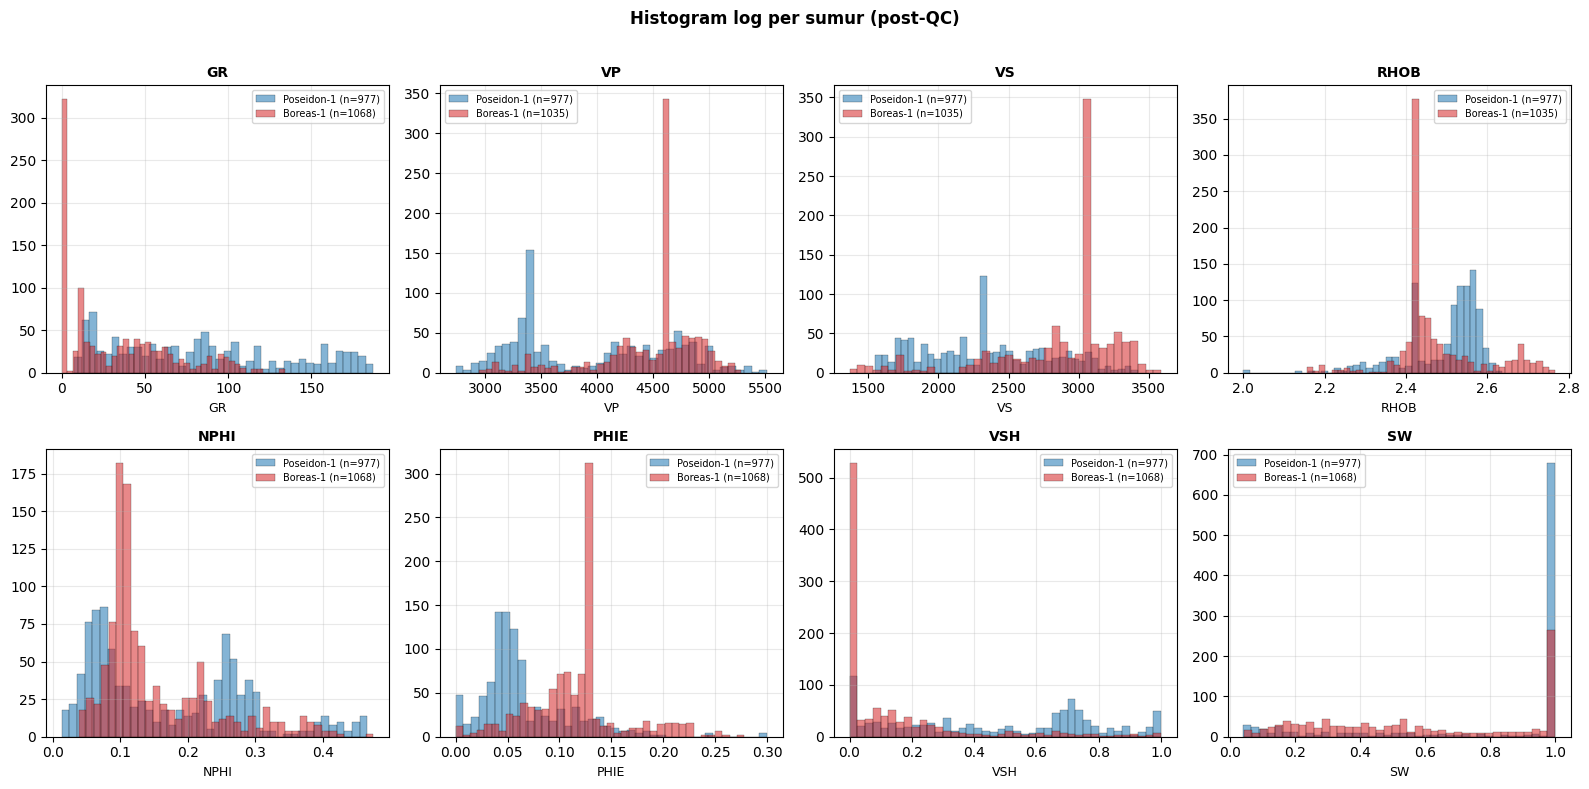

(<Figure size 1600x800 with 8 Axes>,
 array([<Axes: title={'center': 'GR'}, xlabel='GR'>,
        <Axes: title={'center': 'VP'}, xlabel='VP'>,
        <Axes: title={'center': 'VS'}, xlabel='VS'>,
        <Axes: title={'center': 'RHOB'}, xlabel='RHOB'>,
        <Axes: title={'center': 'NPHI'}, xlabel='NPHI'>,
        <Axes: title={'center': 'PHIE'}, xlabel='PHIE'>,
        <Axes: title={'center': 'VSH'}, xlabel='VSH'>,
        <Axes: title={'center': 'SW'}, xlabel='SW'>], dtype=object))

In [13]:
plot_utils.plot_log_histograms(
    WELL_DFRAMES,
    cols=["GR","VP","VS","RHOB","NPHI","PHIE","VSH","SW"],
    figsize=(16, 8),
    title="Histogram log per sumur (post-QC)"
)


## Cell 6 — 9-Track composite well log plot

Menggunakan `plot_utils.plot_well_logs_9track`:
- T1: GR + VSH overlay
- T2: RHOB + NPHI dengan gas crossover fill (kuning)
- T3: RD + RS log scale (atau RT fallback)
- T4: VP + VS (model overlay tersedia setelah NB2)
- T5: VSH + PHIE dengan color fill (darkgreen→VSH, yellow VSH→1, cyan→PHIE)
- T6: SW dengan magenta fill di SW < 0.5
- T7: PI
- T8: SI
- T9: LITHO (kosong di NB1; akan diisi di NB2)


  Plotting Poseidon-1 ...


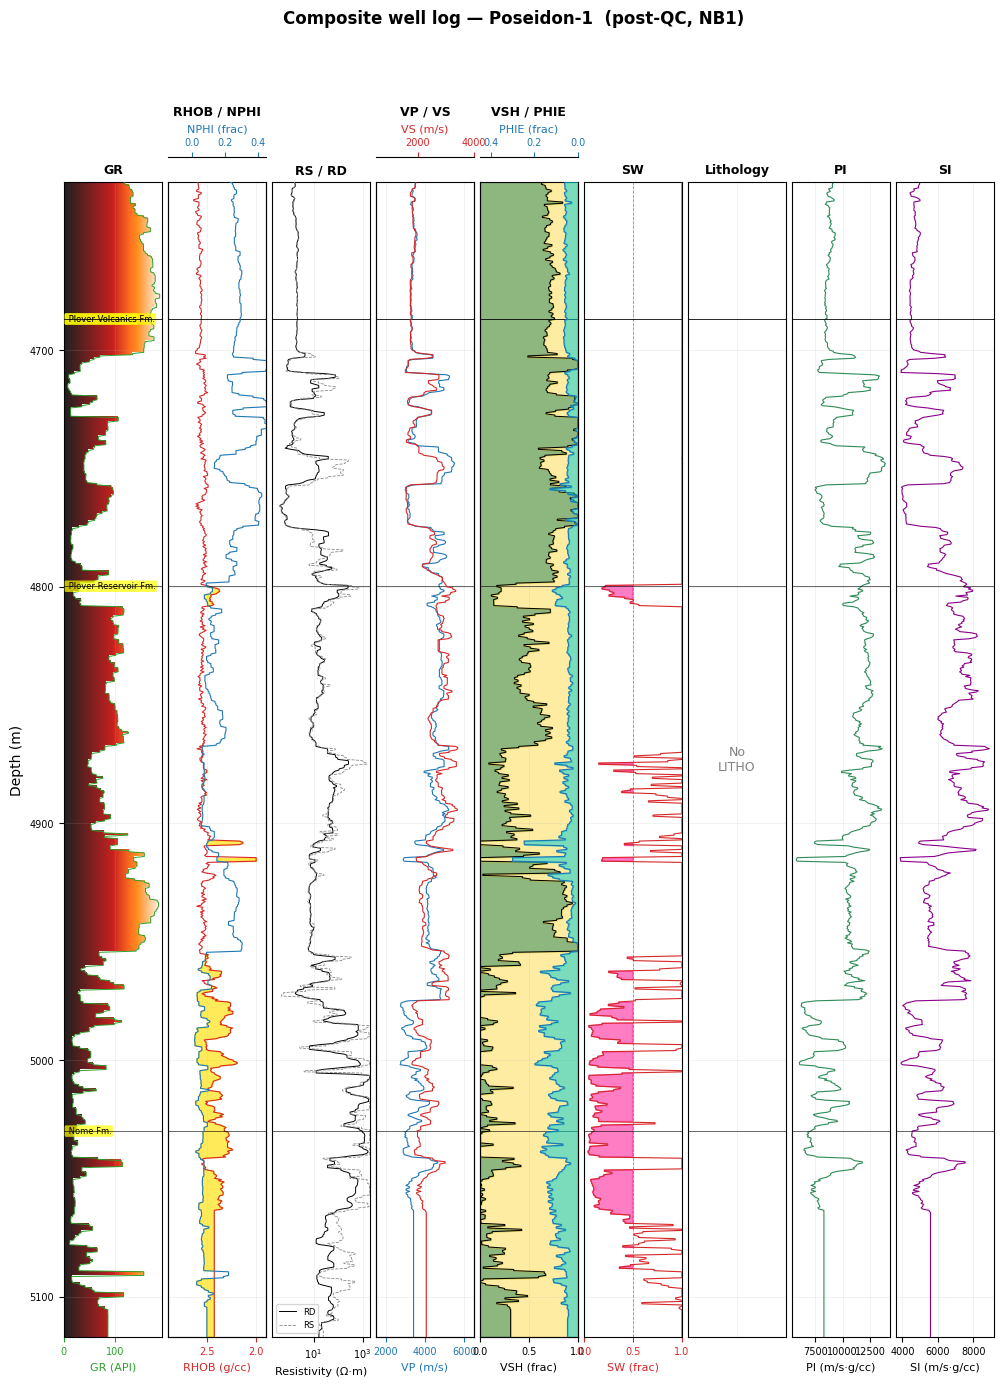


  Plotting Boreas-1 ...


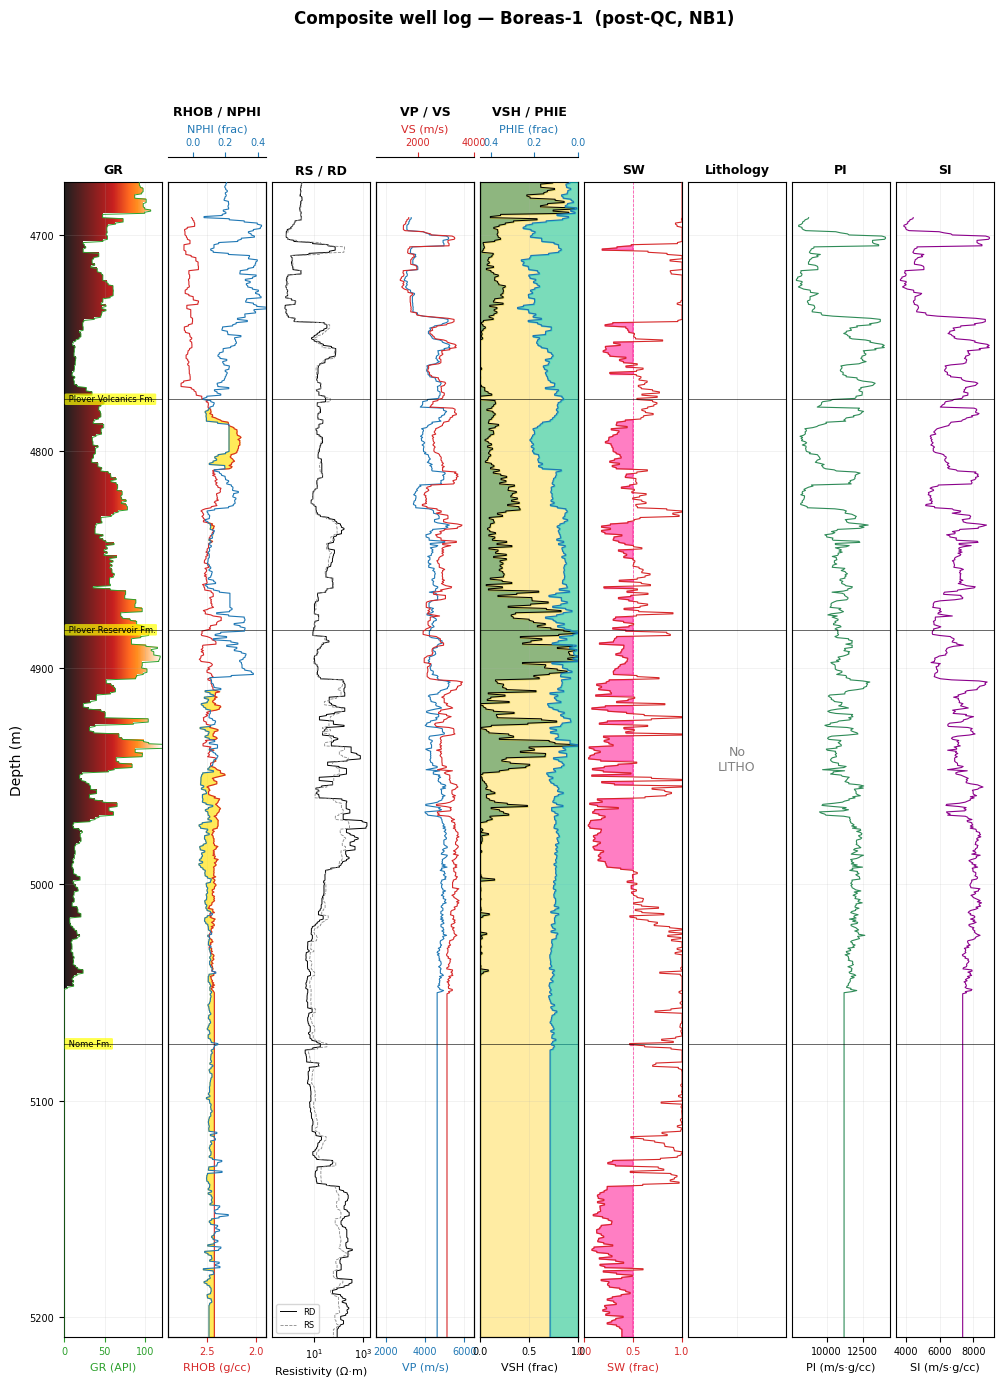

In [14]:
for well_id, df in WELL_DFRAMES.items():
    print(f"\n  Plotting {well_id} ...")
    plot_utils.plot_well_logs_9track(
        df, well_id=well_id,
        tops=WELL_TOPS.get(well_id),
        depth_col="DEPTH",
        title_suffix="  (post-QC, NB1)",
    )


## Cell 7 — Empirical clipping bounds (P10 fix)

Hitung bounds P1-P99 dari data gabungan kedua sumur — untuk clipping yang lebih
realistis di NB6 daripada bound default. Disimpan ke CFG dan ke JSON terpisah.

In [15]:
# ─── Compute empirical P1-P99 bounds ───
combined_data = pd.concat(
    [df.assign(WELL=wid) for wid, df in WELL_DFRAMES.items()],
    ignore_index=True
)

empirical_bounds = {}
for col in ["VP", "VS", "RHOB", "NPHI", "GR", "PHIE", "VSH", "SW", "PI", "SI", "VPVS"]:
    if col not in combined_data.columns:
        continue
    v = combined_data[col].dropna().values
    if v.size < 10:
        continue
    p1, p50, p99 = np.percentile(v, [1, 50, 99])
    empirical_bounds[col] = {
        "p1":  float(p1),
        "p50": float(p50),
        "p99": float(p99),
        "mean": float(v.mean()),
        "std":  float(v.std()),
        "n":    int(v.size),
    }

print("=" * 72)
print(f"  Empirical clipping bounds (P1-P99) dari {sum(b['n'] for b in empirical_bounds.values())} samples")
print("=" * 72)
print(f"  {'Log':6s}  {'P1':>10s}  {'P50':>10s}  {'P99':>10s}  {'mean':>10s}  {'std':>10s}  {'n':>6s}")
print("  " + "-" * 70)
for col, b in empirical_bounds.items():
    print(f"  {col:6s}  {b['p1']:>10.3f}  {b['p50']:>10.3f}  {b['p99']:>10.3f}  "
          f"{b['mean']:>10.3f}  {b['std']:>10.3f}  {b['n']:>6d}")

# ─── Inject ke CFG untuk dipakai NB6 ───
CFG["empirical_bounds"] = empirical_bounds

# ─── Specific bounds untuk PHIE/VSH/SW yang akan dipakai NB6 (P10) ───
def _b(col, default):
    if col in empirical_bounds:
        return (empirical_bounds[col]["p1"], empirical_bounds[col]["p99"])
    return default

CFG["clip_bounds_inversion"] = {
    "PHIE": _b("PHIE", (0.001, 0.45)),
    "VSH" : _b("VSH",  (0.001, 1.0)),
    "SW"  : _b("SW",   (0.001, 1.0)),
    "LR":   (1e9,   2e10),   # Lambda-Rho: Pa·(kg/m³), range wajar
    "MR":   (5e8,   8e9),    # Mu-Rho: Pa·(kg/m³), range wajar
    "RD":   (0.1,   1000.0), # Resistivity: Ohm·m
}
print(f"\n  Inversion clip bounds (P10):")
for col, bnd in CFG["clip_bounds_inversion"].items():
    print(f"    {col:6s}: [{bnd[0]:.4f}, {bnd[1]:.4f}]")


  Empirical clipping bounds (P1-P99) dari 22297 samples
  Log             P1         P50         P99        mean         std       n
  ----------------------------------------------------------------------
  VP        2915.060    4426.194    5224.716    4216.815     638.560    2012
  VS        1495.505    2721.619    3417.389    2606.206     523.061    2012
  RHOB         2.189       2.470       2.727       2.483       0.102    2012
  NPHI         0.027       0.117       0.449       0.162       0.101    2045
  GR           0.000      45.901     178.533      56.561      49.918    2045
  PHIE         0.000       0.091       0.240       0.092       0.052    2045
  VSH          0.000       0.176       1.000       0.301       0.319    2045
  SW           0.056       0.873       1.000       0.683       0.346    2045
  PI        6588.936   11158.736   13565.862   10473.618    1646.514    2012
  SI        3946.979    6811.683    8635.551    6458.509    1270.528    2012
  VPVS         1.454    

## Cell 8 — Save outputs untuk NB2-NB6

In [16]:
io = PipelineIO(stage="01_well_qc")

# 1) DataFrames per sumur
for well_id, df in WELL_DFRAMES.items():
    io.save_df(well_id, df)

# 2) Tops dict
io.save_pkl("WELL_TOPS", WELL_TOPS)

# 3) CFG global (digunakan NB2-NB6)
io.save_pkl("CFG", CFG)

# 4) Empirical bounds JSON terpisah (untuk inspeksi manual)
io.save_json("empirical_clip_bounds", empirical_bounds)

# 5) Metadata ringkas
io.save_json("metadata", {
    "wells_processed": list(WELL_DFRAMES.keys()),
    "interval_top"   : CFG["geology"]["top_start"],
    "interval_bottom": CFG["geology"]["top_end"] or "TD",
    "n_samples_per_well": {k: len(v) for k, v in WELL_DFRAMES.items()},
    "rho_clay"       : CFG["rock_physics"]["rho_clay"],
    "phi_c"          : CFG["rock_physics"]["phi_c"],
    "calibration_flags": {
        "calibrate_corr_length": CFG["inversion_2d"]["calibrate_corr_length"],
        "calibrate_sigma0"     : CFG["inversion_2d"]["calibrate_sigma0"],
        "calibrate_noise"      : CFG["inversion_2d"]["calibrate_noise"],
    },
    "n_qsamp"            : CFG["inversion_2d"]["n_qsamp"],
    "lateral_blend_lambda": CFG["inversion_2d"]["lateral_blend_lambda"],
    "n_pseudo_wells"      : CFG["lfm"]["n_pseudo_wells"],
})

io.list_files()

print("\n" + "=" * 72)
print("  ✓ NB1 selesai — siap lanjut ke NB2 (Conditioning + RPM + GMM)")
print("=" * 72)


  [01_well_qc] 8 file(s) di pipeline_data\01_well_qc:
    • Boreas-1.csv                                 165.3 KB
    • Boreas-1.parquet                              89.8 KB
    • CFG.pkl                                        5.0 KB
    • empirical_clip_bounds.json                     1.8 KB
    • metadata.json                                  0.4 KB
    • Poseidon-1.csv                               157.8 KB
    • Poseidon-1.parquet                           104.1 KB
    • WELL_TOPS.pkl                                  0.8 KB

  ✓ NB1 selesai — siap lanjut ke NB2 (Conditioning + RPM + GMM)
